# -------------------------------
# 📊 PROJECT 1: House Price Prediction (Linear Regression)
# -------------------------------

## Step 1 — Generate / Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
np.random.seed(42)
n = 300

area        = np.random.randint(500, 3500, n)          # sq ft
bedrooms    = np.random.randint(1, 6, n)
age         = np.random.randint(0, 40, n)              # years
location    = np.random.choice(['Urban', 'Suburban', 'Rural'], n)

loc_map     = {'Urban': 30, 'Suburban': 15, 'Rural': 0}
loc_bonus   = np.array([loc_map[l] for l in location])

# Price in Lakhs  (realistic formula + noise)
price = (area * 0.025 + bedrooms * 3 + loc_bonus - age * 0.5
         + np.random.normal(0, 5, n))
price = np.clip(price, 10, 200)   # keep between 10–200 L

house_df = pd.DataFrame({
    'Area_sqft'   : area,
    'Bedrooms'    : bedrooms,
    'Age_years'   : age,
    'Location'    : location,
    'Price_Lakhs' : price.round(2)
})

print('Shape:', house_df.shape)
house_df.head(10)

Shape: (300, 5)


,Area_sqft,Bedrooms,Age_years,Location,Price_Lakhs
0,1360,2,21,Suburban,48.11
1,1794,2,16,Rural,37.20
2,1630,3,6,Urban,74.13
3,1595,5,24,Urban,75.32
4,2138,1,3,Suburban,63.84
5,2669,4,35,Suburban,79.79
6,966,1,5,Suburban,38.45
7,1738,4,30,Rural,38.58
8,830,1,18,Urban,48.30
9,1982,5,38,Urban,77.77


## Step 2 — EDA (Exploratory Data Analysis)

In [3]:
print('=== Basic Info ===')
print(house_df.describe())
print('\nMissing values:\n', house_df.isnull().sum())

=== Basic Info ===
         Area_sqft    Bedrooms   Age_years  Price_Lakhs
count   300.000000  300.000000  300.000000   300.000000
mean   2067.576667    3.046667   19.176667    66.730967
std     828.440549    1.459998   11.531205    26.541821
min     501.000000    1.000000    0.000000    10.000000
25%    1368.250000    2.000000    9.000000    46.992500
50%    2087.000000    3.000000   20.000000    67.045000
75%    2753.500000    4.000000   29.000000    86.215000
max    3499.000000    5.000000   39.000000   133.810000

Missing values:
 Area_sqft      0
Bedrooms       0
Age_years      0
Location       0
Price_Lakhs    0
dtype: int64


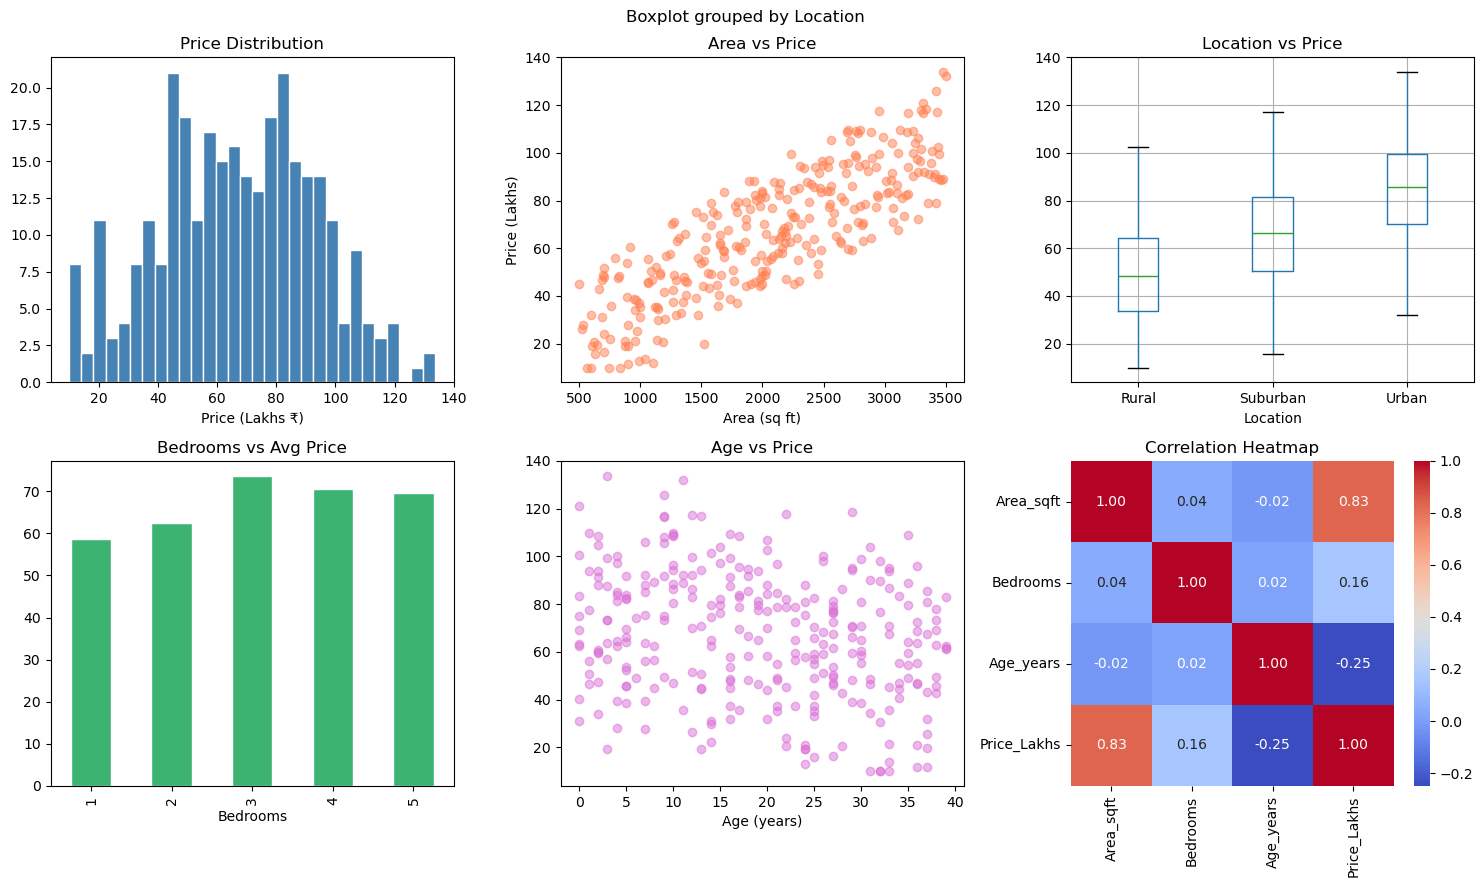

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('🏠 House Price — EDA', fontsize=16, fontweight='bold')

# 1. Price distribution
axes[0,0].hist(house_df['Price_Lakhs'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price (Lakhs ₹)')

# 2. Area vs Price
axes[0,1].scatter(house_df['Area_sqft'], house_df['Price_Lakhs'],
                  alpha=0.5, color='coral')
axes[0,1].set_title('Area vs Price')
axes[0,1].set_xlabel('Area (sq ft)')
axes[0,1].set_ylabel('Price (Lakhs)')

# 3. Location vs Price box
house_df.boxplot(column='Price_Lakhs', by='Location', ax=axes[0,2])
axes[0,2].set_title('Location vs Price')
plt.sca(axes[0,2]); plt.title('Location vs Price')

# 4. Bedrooms vs Price
house_df.groupby('Bedrooms')['Price_Lakhs'].mean().plot(kind='bar',
    ax=axes[1,0], color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Bedrooms vs Avg Price')
axes[1,0].set_xlabel('Bedrooms')

# 5. Age vs Price
axes[1,1].scatter(house_df['Age_years'], house_df['Price_Lakhs'],
                  alpha=0.5, color='orchid')
axes[1,1].set_title('Age vs Price')
axes[1,1].set_xlabel('Age (years)')

# 6. Correlation heatmap (numeric only)
num_df = house_df.select_dtypes(include='number')
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

## Step 3 — Preprocessing & Feature Engineering

In [5]:
# Encode 'Location' using Label Encoding
le = LabelEncoder()
house_df['Location_enc'] = le.fit_transform(house_df['Location'])
print('Location encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Features & Target
features = ['Area_sqft', 'Bedrooms', 'Age_years', 'Location_enc']
X_house  = house_df[features]
y_house  = house_df['Price_Lakhs']

# Feature Scaling
scaler_h  = StandardScaler()
X_house_s = scaler_h.fit_transform(X_house)

# Train-Test Split
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_house_s, y_house, test_size=0.2, random_state=42)

print(f'Train: {Xh_train.shape}, Test: {Xh_test.shape}')

Location encoding: {'Rural': np.int64(0), 'Suburban': np.int64(1), 'Urban': np.int64(2)}
Train: (240, 4), Test: (60, 4)


## Step 4 — Train Linear Regression Model

In [6]:
lr_house = LinearRegression()
lr_house.fit(Xh_train, yh_train)

print('✅ Model trained!')
print('\nCoefficients:')
for feat, coef in zip(features, lr_house.coef_):
    print(f'  {feat:15s}: {coef:.4f}')
print(f'  Intercept      : {lr_house.intercept_:.4f}')

✅ Model trained!

Coefficients:
  Area_sqft      : 20.3754
  Bedrooms       : 4.2044
  Age_years      : -5.7215
  Location_enc   : 12.1044
  Intercept      : 66.9306


## Step 5 — Evaluation

In [7]:
yh_pred = lr_house.predict(Xh_test)

mae  = mean_absolute_error(yh_test, yh_pred)
mse  = mean_squared_error(yh_test, yh_pred)
rmse = np.sqrt(mse)
r2   = r2_score(yh_test, yh_pred)

print('='*40)
print('  📈 LINEAR REGRESSION — METRICS')
print('='*40)
print(f'  MAE  : ₹{mae:.2f} Lakhs')
print(f'  MSE  : {mse:.2f}')
print(f'  RMSE : ₹{rmse:.2f} Lakhs')
print(f'  R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)')
print('='*40)

  📈 LINEAR REGRESSION — METRICS
  MAE  : ₹4.16 Lakhs
  MSE  : 27.80
  RMSE : ₹5.27 Lakhs
  R²   : 0.9634  (96.3% variance explained)


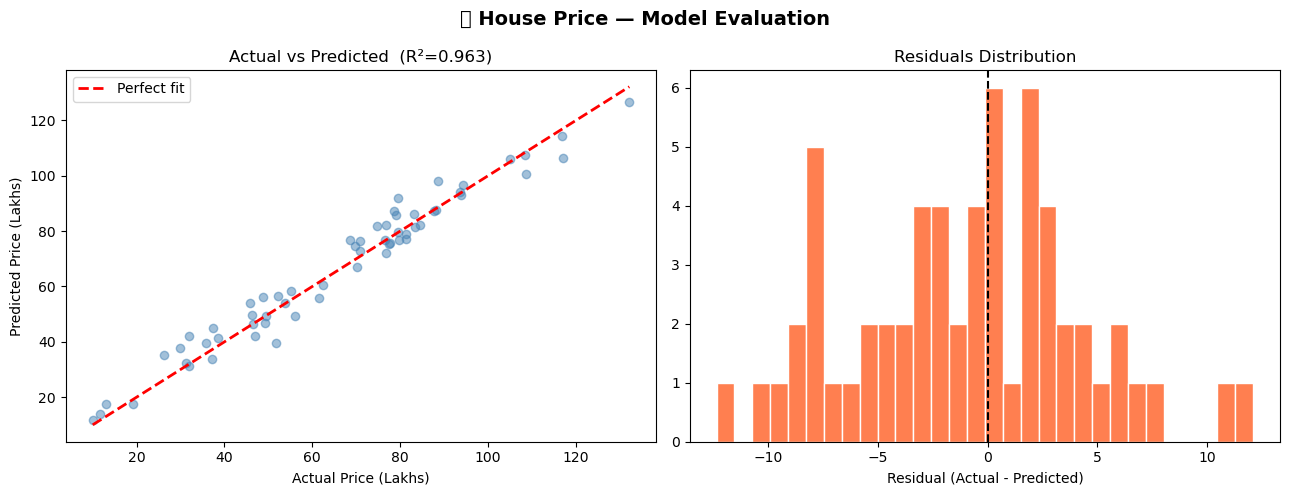

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('🏠 House Price — Model Evaluation', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(yh_test, yh_pred, alpha=0.5, color='steelblue')
mn, mx = yh_test.min(), yh_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Price (Lakhs)')
axes[0].set_ylabel('Predicted Price (Lakhs)')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})')
axes[0].legend()

# Residuals
residuals = yh_test - yh_pred
axes[1].hist(residuals, bins=30, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

## Step 6 — Predict a New House

In [9]:
# ✏️  Change these values to predict any house
new_house = {
    'Area_sqft'   : 1800,
    'Bedrooms'    : 3,
    'Age_years'   : 5,
    'Location'    : 'Urban'   # Urban / Suburban / Rural
}

loc_enc   = le.transform([new_house['Location']])[0]
new_input = np.array([[new_house['Area_sqft'],
                        new_house['Bedrooms'],
                        new_house['Age_years'],
                        loc_enc]])
new_scaled = scaler_h.transform(new_input)
prediction = lr_house.predict(new_scaled)[0]

print('🏠 House Details:')
for k, v in new_house.items():
    print(f'   {k}: {v}')
print(f'\n👉 Predicted Price = ₹{prediction:.2f} Lakhs')

🏠 House Details:
   Area_sqft: 1800
   Bedrooms: 3
   Age_years: 5
   Location: Urban

👉 Predicted Price = ₹81.93 Lakhs
